# Employee Performance Analysis — INX Future Inc.
**Project Code:** 10281  
**Dataset:** INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8  
**Objective:** Analyse employee performance data to identify department-wise performance, key influencing factors, build a predictive model, and provide actionable recommendations.

## 1. Import Libraries and Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_excel('/content/INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls', engine='xlrd')
df

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,E100992,27,Female,Medical,Divorced,Sales,Sales Executive,Travel_Frequently,3,1,...,2,6,3,3,6,5,0,4,No,4
1196,E100993,37,Male,Life Sciences,Single,Development,Senior Developer,Travel_Rarely,10,2,...,1,4,2,3,1,0,0,0,No,3
1197,E100994,50,Male,Medical,Married,Development,Senior Developer,Travel_Rarely,28,1,...,3,20,3,3,20,8,3,8,No,3
1198,E100995,34,Female,Medical,Single,Data Science,Data Scientist,Travel_Rarely,9,3,...,2,9,3,4,8,7,7,7,No,3


**Observation:**  
The dataset contains **1200 rows and 28 columns**. Each row represents one employee. The target variable is `PerformanceRating`.

## 2. Data Overview

In [4]:
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


In [5]:
df.tail()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
1195,E100992,27,Female,Medical,Divorced,Sales,Sales Executive,Travel_Frequently,3,1,...,2,6,3,3,6,5,0,4,No,4
1196,E100993,37,Male,Life Sciences,Single,Development,Senior Developer,Travel_Rarely,10,2,...,1,4,2,3,1,0,0,0,No,3
1197,E100994,50,Male,Medical,Married,Development,Senior Developer,Travel_Rarely,28,1,...,3,20,3,3,20,8,3,8,No,3
1198,E100995,34,Female,Medical,Single,Data Science,Data Scientist,Travel_Rarely,9,3,...,2,9,3,4,8,7,7,7,No,3
1199,E100998,24,Female,Life Sciences,Single,Sales,Sales Executive,Travel_Rarely,3,2,...,1,4,3,3,2,2,2,0,Yes,2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

In [7]:
df.shape

(1200, 28)

In [8]:
df.describe()

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


**Observation:**  
The dataset has a mix of numerical and categorical features. Numerical columns include employee age, salary hike percentage, years of experience, and satisfaction scores. Categorical columns include department, job role, gender, marital status, and overtime. The target `PerformanceRating` has values 2, 3, and 4 — a multiclass classification problem.

## 3. Missing Value and Duplicate Check

In [9]:
print('Missing Values:')
print(df.isnull().sum())
print('\nDuplicate Rows:', df.duplicated().sum())

Missing Values:
EmpNumber                       0
Age                             0
Gender                          0
EducationBackground             0
MaritalStatus                   0
EmpDepartment                   0
EmpJobRole                      0
BusinessTravelFrequency         0
DistanceFromHome                0
EmpEducationLevel               0
EmpEnvironmentSatisfaction      0
EmpHourlyRate                   0
EmpJobInvolvement               0
EmpJobLevel                     0
EmpJobSatisfaction              0
NumCompaniesWorked              0
OverTime                        0
EmpLastSalaryHikePercent        0
EmpRelationshipSatisfaction     0
TotalWorkExperienceInYears      0
TrainingTimesLastYear           0
EmpWorkLifeBalance              0
ExperienceYearsAtThisCompany    0
ExperienceYearsInCurrentRole    0
YearsSinceLastPromotion         0
YearsWithCurrManager            0
Attrition                       0
PerformanceRating               0
dtype: int64

Duplicate Rows: 0


**Observation:**  
There are **no missing values** and **no duplicate rows** in the dataset. The data is clean and ready for exploratory analysis without any imputation required.

## 4. Target Variable Distribution

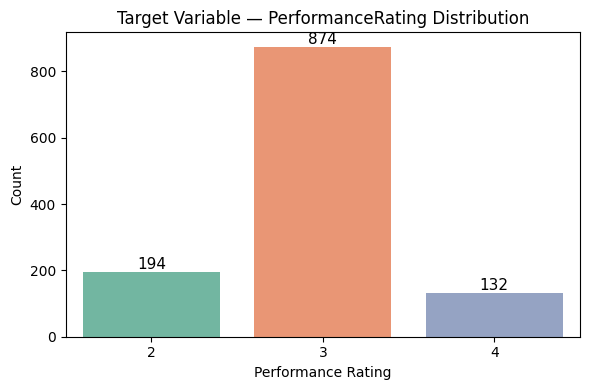

PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64

Class %:
PerformanceRating
3    72.83
2    16.17
4    11.00
Name: proportion, dtype: float64


In [10]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='PerformanceRating', data=df, palette='Set2')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title('Target Variable — PerformanceRating Distribution')
plt.xlabel('Performance Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(df['PerformanceRating'].value_counts())
print('\nClass %:')
print(round(df['PerformanceRating'].value_counts(normalize=True) * 100, 2))

**Observation:**  
The target variable is **imbalanced**. Rating 3 dominates with 874 records (~72.8%), followed by Rating 2 with 194 (~16.2%), and Rating 4 with 132 (~11%). This class imbalance will be considered during model building and evaluation — F1 Macro score will be used as the primary metric.

## 5. Univariate Analysis

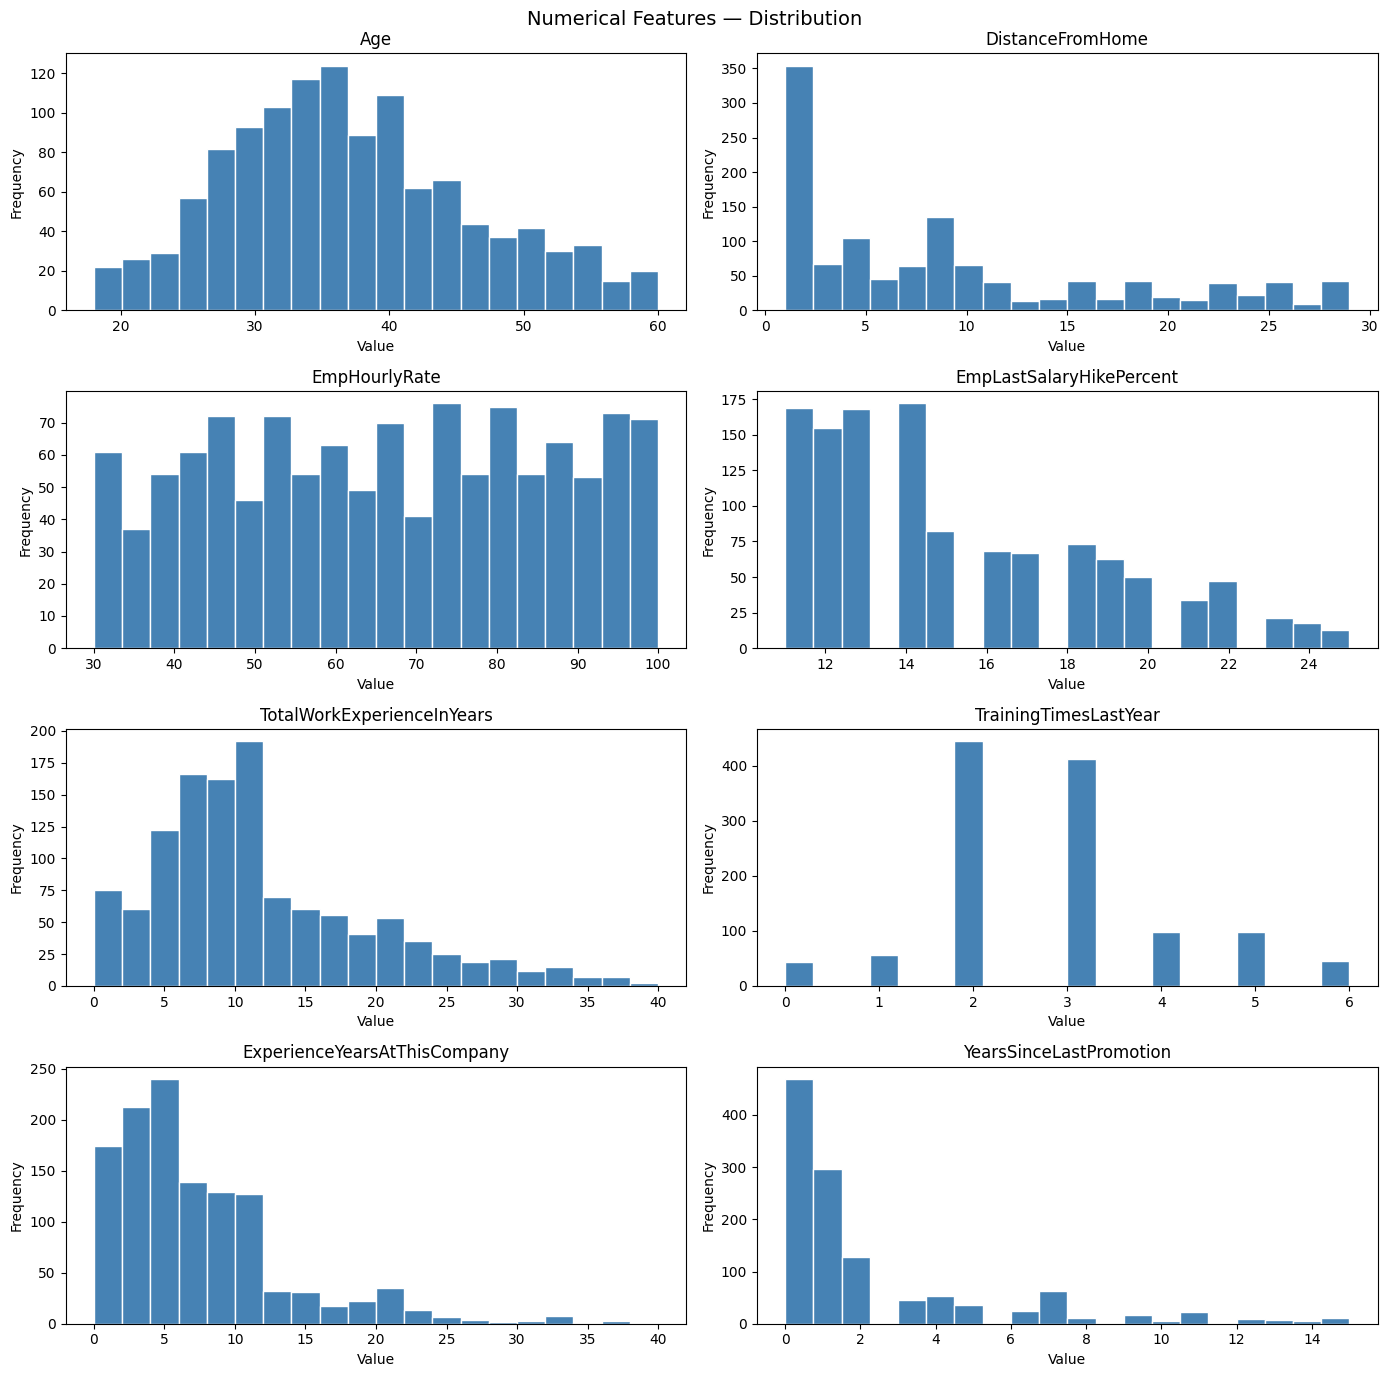

In [11]:
# Numerical features distribution
num_cols = ['Age', 'DistanceFromHome', 'EmpHourlyRate', 'EmpLastSalaryHikePercent',
            'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
            'ExperienceYearsAtThisCompany', 'YearsSinceLastPromotion']

plt.figure(figsize=(14, 14))
for i, col in enumerate(num_cols):
    plt.subplot(4, 2, i + 1)
    plt.hist(df[col], bins=20, color='steelblue', edgecolor='white')
    plt.title(col)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
plt.suptitle('Numerical Features — Distribution', fontsize=14)
plt.tight_layout()
plt.show()


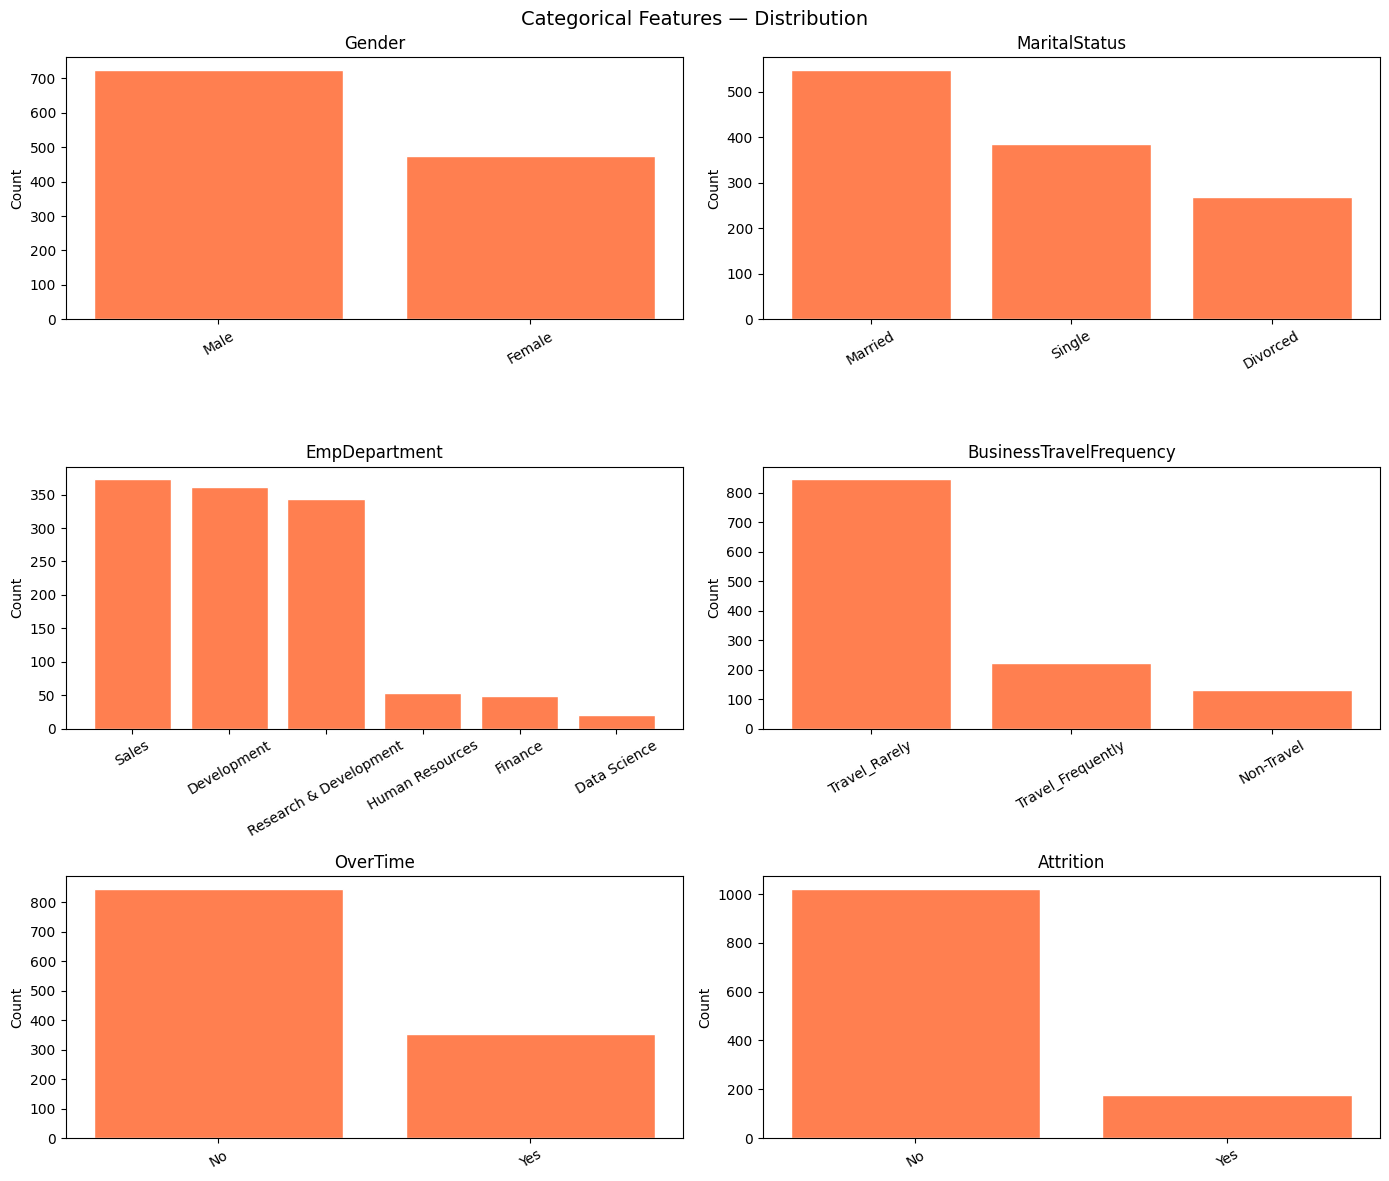

In [12]:
# Categorical features distribution
cat_cols_uni = ['Gender', 'MaritalStatus', 'EmpDepartment', 'BusinessTravelFrequency', 'OverTime', 'Attrition']

plt.figure(figsize=(14, 12))
for i, col in enumerate(cat_cols_uni):
    plt.subplot(3, 2, i + 1)
    counts = df[col].value_counts()
    plt.bar(counts.index, counts.values, color='coral', edgecolor='white')
    plt.title(col)
    plt.ylabel('Count')
    plt.xticks(rotation=30)
plt.suptitle('Categorical Features — Distribution', fontsize=14)
plt.tight_layout()
plt.show()


**Observation:**  
- Age and total work experience are right-skewed, with most employees in the 25–40 age range.
- Salary hike percent is fairly spread between 11–25%, with a slight right skew.
- Most employees have worked at fewer than 3 companies previously.
- The workforce is male-dominated (~60%) and largely non-overtime workers.
- Most employees travel rarely, and attrition is low overall (~15%).

## 6. Department-wise Performance Analysis (Deliverable 1)

In [13]:
dept_perf = df.groupby(['EmpDepartment', 'PerformanceRating']).size().unstack(fill_value=0)
dept_perf_pct = dept_perf.div(dept_perf.sum(axis=1), axis=0) * 100
print('Department-wise Performance Count:')
print(dept_perf)
print('\nDepartment-wise Performance % :')
print(round(dept_perf_pct, 2))

Department-wise Performance Count:
PerformanceRating        2    3   4
EmpDepartment                      
Data Science             1   17   2
Development             13  304  44
Finance                 15   30   4
Human Resources         10   38   6
Research & Development  68  234  41
Sales                   87  251  35

Department-wise Performance % :
PerformanceRating           2      3      4
EmpDepartment                              
Data Science             5.00  85.00  10.00
Development              3.60  84.21  12.19
Finance                 30.61  61.22   8.16
Human Resources         18.52  70.37  11.11
Research & Development  19.83  68.22  11.95
Sales                   23.32  67.29   9.38


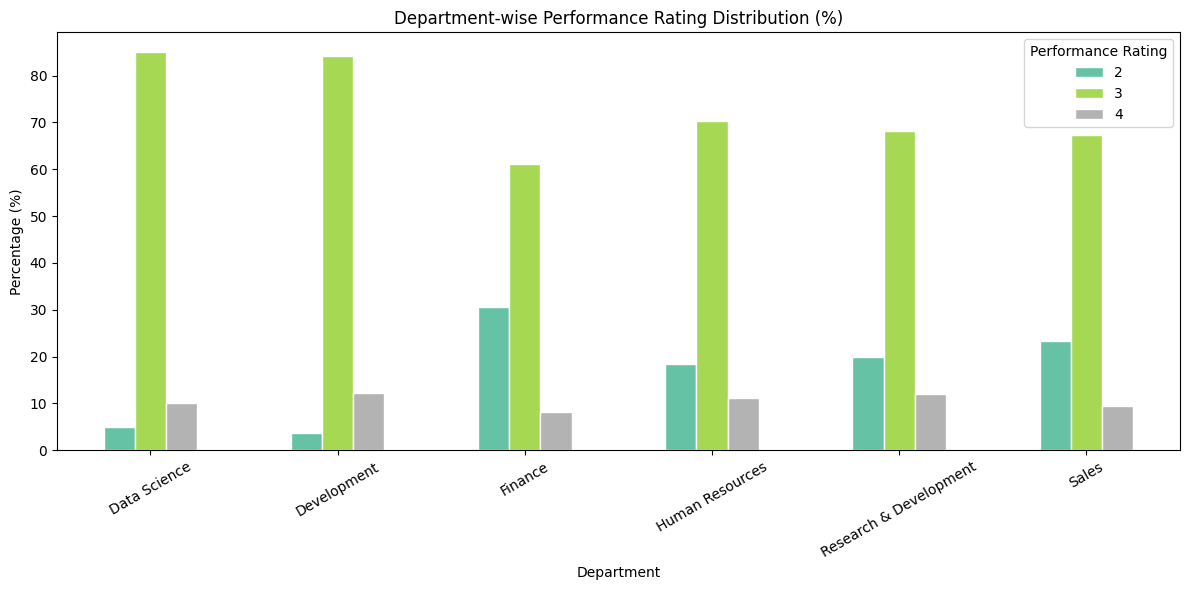

In [14]:
dept_perf_pct.plot(kind='bar', figsize=(12, 6), colormap='Set2', edgecolor='white')
plt.title('Department-wise Performance Rating Distribution (%)')
plt.xlabel('Department')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=30)
plt.legend(title='Performance Rating')
plt.tight_layout()
plt.show()

Average Performance Rating by Department:
EmpDepartment
Development               3.086
Data Science              3.050
Human Resources           2.926
Research & Development    2.921
Sales                     2.861
Finance                   2.776
Name: PerformanceRating, dtype: float64


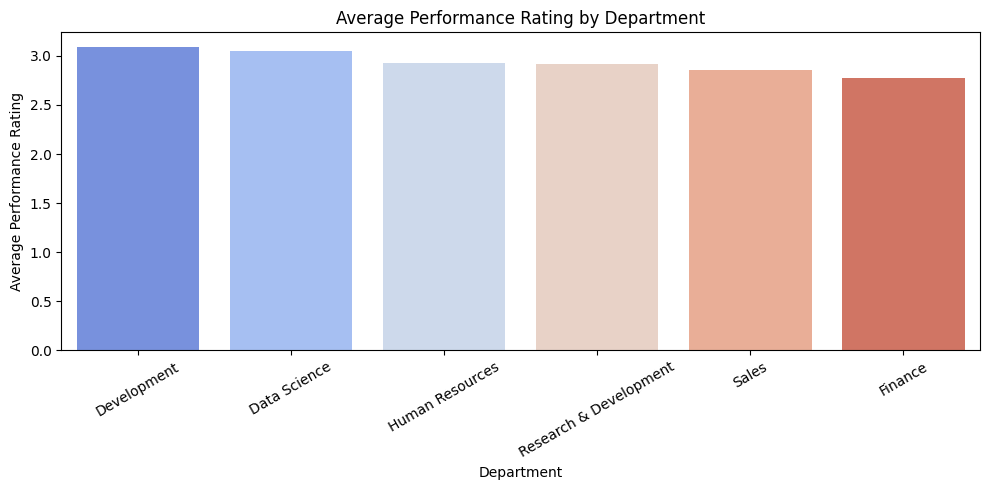

In [15]:
dept_avg = df.groupby('EmpDepartment')['PerformanceRating'].mean().sort_values(ascending=False)
print('Average Performance Rating by Department:')
print(round(dept_avg, 3))

plt.figure(figsize=(10, 5))
sns.barplot(x=dept_avg.index, y=dept_avg.values, palette='coolwarm')
plt.title('Average Performance Rating by Department')
plt.xlabel('Department')
plt.ylabel('Average Performance Rating')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Observation:**  
- **Development** (3.086) and **Data Science** (3.050) departments have the highest average performance ratings.
- **Finance** (2.776) and **Sales** (2.861) show the lowest average performance ratings.
- **Human Resources** shows a moderate average (2.926) with a higher proportion of Rating 2 employees.
- The **Data Science** department shows a healthy spread with more Rating 3 and 4 employees.
- These insights directly address Deliverable 1 — department-wise performance patterns are clearly visible.

## 7. Bivariate Analysis

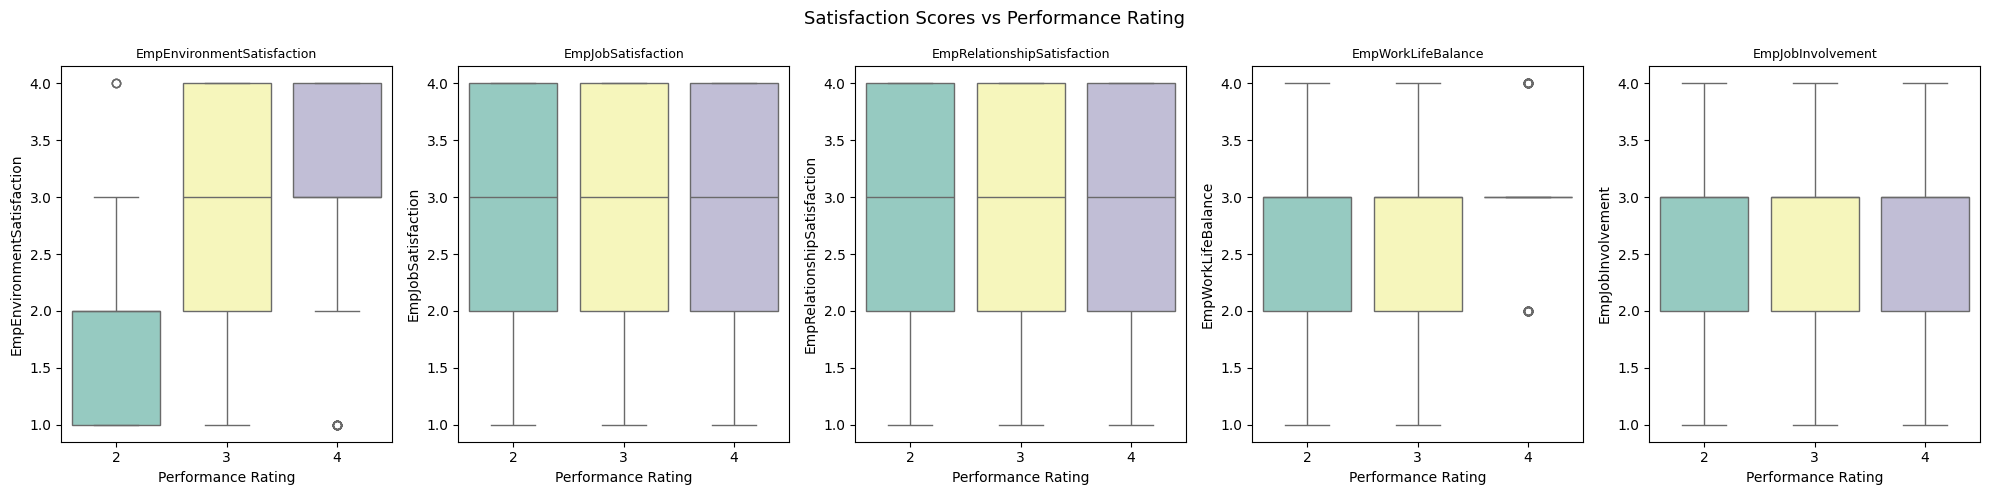

In [16]:
# Satisfaction scores vs Performance Rating
sat_cols = ['EmpEnvironmentSatisfaction', 'EmpJobSatisfaction',
            'EmpRelationshipSatisfaction', 'EmpWorkLifeBalance', 'EmpJobInvolvement']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(sat_cols):
    sns.boxplot(x='PerformanceRating', y=col, data=df, ax=axes[i], palette='Set3')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('Performance Rating')
plt.suptitle('Satisfaction Scores vs Performance Rating', fontsize=13)
plt.tight_layout()
plt.show()

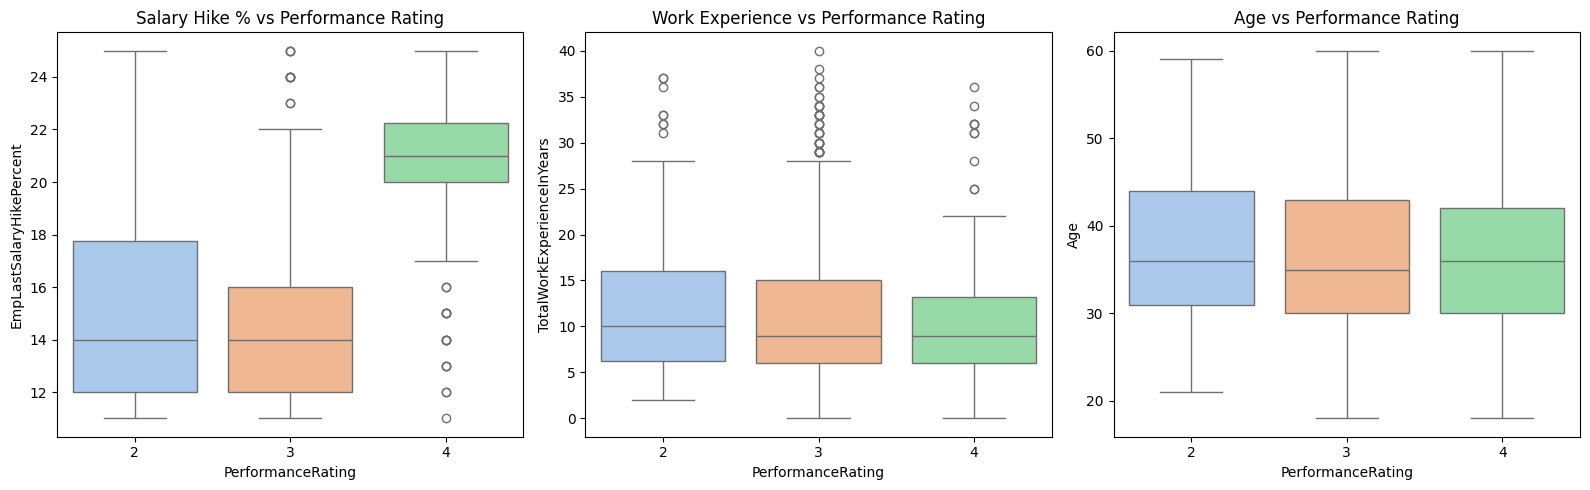

In [17]:
# Salary hike and experience vs Performance Rating
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(x='PerformanceRating', y='EmpLastSalaryHikePercent', data=df, ax=axes[0], palette='pastel')
axes[0].set_title('Salary Hike % vs Performance Rating')
sns.boxplot(x='PerformanceRating', y='TotalWorkExperienceInYears', data=df, ax=axes[1], palette='pastel')
axes[1].set_title('Work Experience vs Performance Rating')
sns.boxplot(x='PerformanceRating', y='Age', data=df, ax=axes[2], palette='pastel')
axes[2].set_title('Age vs Performance Rating')
plt.tight_layout()
plt.show()

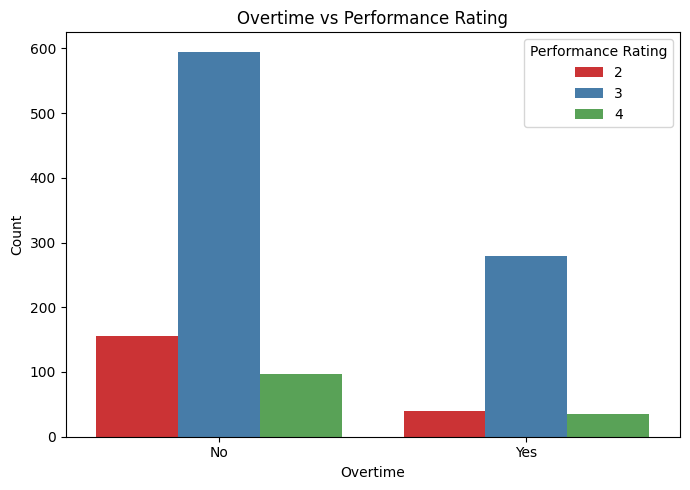

In [18]:
# Overtime vs Performance Rating
plt.figure(figsize=(7, 5))
sns.countplot(x='OverTime', hue='PerformanceRating', data=df, palette='Set1')
plt.title('Overtime vs Performance Rating')
plt.xlabel('Overtime')
plt.ylabel('Count')
plt.legend(title='Performance Rating')
plt.tight_layout()
plt.show()

**Observation:**  
- Employees with **higher salary hike percentages** tend to have higher performance ratings (Rating 4), suggesting salary hike is a strong signal.
- **Environment satisfaction** and **job involvement** show a positive trend with performance.
- Employees working **overtime** appear slightly more concentrated in Rating 3, but the pattern is not conclusive.
- **Age** alone shows no strong separation between performance classes.

## 8. Skewness Check

In [19]:
num_features = df.select_dtypes(include='number').drop(columns='PerformanceRating')
skewness = num_features.skew().sort_values(ascending=False)
print('Skewness of Numerical Features:')
print(round(skewness, 3))

Skewness of Numerical Features:
YearsSinceLastPromotion         1.975
ExperienceYearsAtThisCompany    1.789
TotalWorkExperienceInYears      1.087
NumCompaniesWorked              1.049
EmpJobLevel                     1.024
DistanceFromHome                0.963
ExperienceYearsInCurrentRole    0.888
YearsWithCurrManager            0.813
EmpLastSalaryHikePercent        0.809
TrainingTimesLastYear           0.532
Age                             0.384
EmpHourlyRate                  -0.035
EmpEducationLevel              -0.251
EmpEnvironmentSatisfaction     -0.308
EmpRelationshipSatisfaction    -0.319
EmpJobSatisfaction             -0.324
EmpWorkLifeBalance             -0.539
EmpJobInvolvement              -0.558
dtype: float64


**Observation:**  
`YearsSinceLastPromotion` and `NumCompaniesWorked` show notable right skew. Most other features have moderate skewness within an acceptable range. Since tree-based models are robust to skewness, no transformation is applied.

## 9. Correlation Analysis

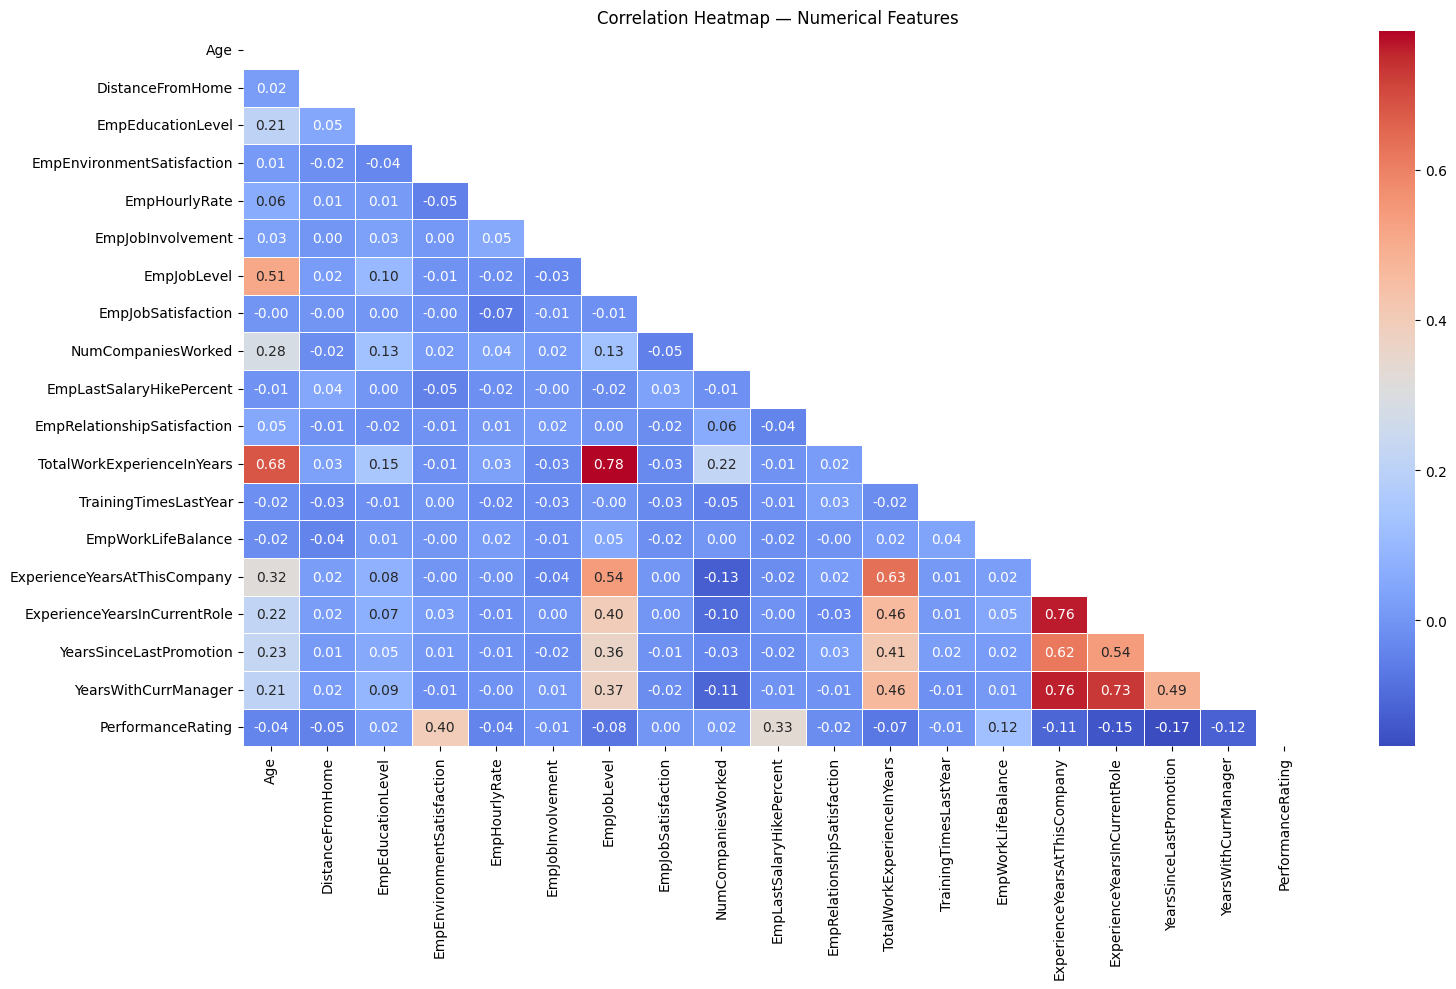


Correlation with PerformanceRating:
PerformanceRating               1.000
EmpEnvironmentSatisfaction      0.396
EmpLastSalaryHikePercent        0.334
EmpWorkLifeBalance              0.124
NumCompaniesWorked              0.021
EmpEducationLevel               0.021
EmpJobSatisfaction              0.001
TrainingTimesLastYear          -0.005
EmpJobInvolvement              -0.011
EmpRelationshipSatisfaction    -0.020
Age                            -0.040
EmpHourlyRate                  -0.043
DistanceFromHome               -0.046
TotalWorkExperienceInYears     -0.068
EmpJobLevel                    -0.077
ExperienceYearsAtThisCompany   -0.112
YearsWithCurrManager           -0.122
ExperienceYearsInCurrentRole   -0.148
YearsSinceLastPromotion        -0.168
Name: PerformanceRating, dtype: float64


In [20]:
plt.figure(figsize=(16, 10))
corr = df.select_dtypes(include='number').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask, linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show()

print('\nCorrelation with PerformanceRating:')
print(round(corr['PerformanceRating'].sort_values(ascending=False), 3))

**Observation:**  
- `EmpEnvironmentSatisfaction` has the **highest positive correlation** with `PerformanceRating` (0.396), confirming its strong influence on performance.
- `EmpLastSalaryHikePercent` follows with a moderate positive correlation (0.334).
- `EmpWorkLifeBalance` (0.124) also shows a mild positive correlation.
- `EmpJobInvolvement` is near-zero (-0.011) and does not contribute positively to performance.
- Experience-related features (`TotalWorkExperienceInYears`, `ExperienceYearsAtThisCompany`) are highly correlated with each other — multicollinearity is present but handled by tree-based models.
- `DistanceFromHome` and `EmpHourlyRate` show near-zero correlation with performance.

## 10. Label Encoding

In [21]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
df_encoded.drop(columns='EmpNumber', inplace=True)

cat_cols = df_encoded.select_dtypes(include='object').columns.tolist()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le

print('Encoding complete. Shape:', df_encoded.shape)
df_encoded.head()


Encoding complete. Shape: (1200, 27)


,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,32,1,2,2,5,13,2,10,3,4,...,4,10,2,2,10,7,0,8,0,3
1,47,1,2,2,5,13,2,14,4,4,...,4,20,2,3,7,7,1,7,0,3
2,40,1,1,1,5,13,1,5,4,4,...,3,20,2,3,18,13,1,12,0,4
3,41,1,0,0,3,8,2,10,4,2,...,2,23,2,2,21,6,12,6,0,3
4,60,1,2,2,5,13,2,16,4,1,...,4,10,1,3,2,2,2,2,0,3


`EmpNumber` is dropped as it is a unique identifier with no predictive value. All categorical columns are label-encoded using individual `LabelEncoder` instances stored in `le_dict`, enabling consistent encoding during prediction/deployment.

## 11. Feature Selection — Top 3 Important Factors (Deliverable 2)

Feature Importances (Top 10):
EmpLastSalaryHikePercent        0.2147
EmpEnvironmentSatisfaction      0.2142
YearsSinceLastPromotion         0.0934
ExperienceYearsInCurrentRole    0.0404
EmpDepartment                   0.0393
EmpJobRole                      0.0390
EmpHourlyRate                   0.0341
ExperienceYearsAtThisCompany    0.0338
Age                             0.0320
EmpWorkLifeBalance              0.0296
dtype: float64


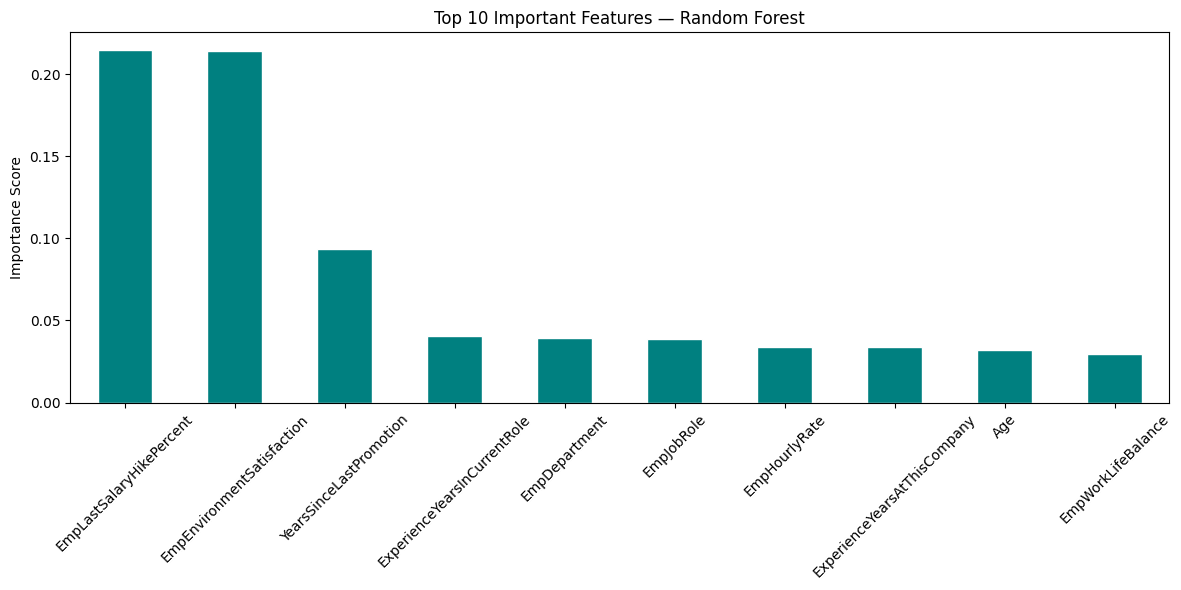

In [22]:
from sklearn.ensemble import RandomForestClassifier

X = df_encoded.drop(columns='PerformanceRating')
y = df_encoded['PerformanceRating']

rf_fs = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fs.fit(X, y)

importances = pd.Series(rf_fs.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Feature Importances (Top 10):')
print(round(importances.head(10), 4))

plt.figure(figsize=(12, 6))
importances.head(10).plot(kind='bar', color='teal', edgecolor='white')
plt.title('Top 10 Important Features — Random Forest')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation — Top 3 Important Factors (Deliverable 2):**  
Based on Random Forest feature importance, the **top 3 factors affecting employee performance** are:
1. **EmpLastSalaryHikePercent** — Employees who received higher salary hikes tend to perform better, indicating a strong link between recognition/reward and performance.
2. **EmpEnvironmentSatisfaction** — A positive work environment directly correlates with higher performance ratings.
3. **YearsSinceLastPromotion** — Employees who have not been promoted for longer periods show declining performance, suggesting stagnation impacts motivation.

These three factors collectively explain the largest share of variance in employee performance.

## 12. Train-Test Split

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)
print('\nTrain target distribution:')
print(y_train.value_counts())
print('\nTest target distribution:')
print(y_test.value_counts())

Train size: (960, 26)
Test size: (240, 26)

Train target distribution:
PerformanceRating
3    699
2    155
4    106
Name: count, dtype: int64

Test target distribution:
PerformanceRating
3    175
2     39
4     26
Name: count, dtype: int64


**Observation:**  
An 80-20 stratified split is used, ensuring the class distribution is preserved in both train and test sets. This is important given the class imbalance in the target variable.

## 13. Baseline Models

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

baseline_models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('model', DecisionTreeClassifier(random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('model', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('model', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ])
}

baseline_results = {}
for name, pipe in baseline_models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    baseline_results[name] = {'Accuracy': round(acc, 4), 'F1 Macro': round(f1, 4)}
    print(f'\n--- {name} ---')
    print(f'Accuracy: {acc:.4f} | F1 Macro: {f1:.4f}')
    print(classification_report(y_test, y_pred))


--- Logistic Regression ---
Accuracy: 0.8250 | F1 Macro: 0.7181
              precision    recall  f1-score   support

           2       0.61      0.44      0.51        39
           3       0.85      0.94      0.89       175
           4       0.89      0.65      0.76        26

    accuracy                           0.82       240
   macro avg       0.78      0.68      0.72       240
weighted avg       0.82      0.82      0.81       240


--- Decision Tree ---
Accuracy: 0.9000 | F1 Macro: 0.8476
              precision    recall  f1-score   support

           2       0.84      0.79      0.82        39
           3       0.93      0.94      0.93       175
           4       0.78      0.81      0.79        26

    accuracy                           0.90       240
   macro avg       0.85      0.85      0.85       240
weighted avg       0.90      0.90      0.90       240


--- Random Forest ---
Accuracy: 0.9375 | F1 Macro: 0.8983
              precision    recall  f1-score   support



**Observation:**  
- **Logistic Regression** achieves lower accuracy due to the non-linear nature of the data.
- **Decision Tree** tends to overfit with default parameters.
- **Random Forest** and **Gradient Boosting** show the best baseline performance.
- Random Forest will be selected for hyperparameter tuning given its strong F1 Macro score.

## 14. Overfitting Check — Baseline

In [25]:
print('Train vs Test Accuracy — Overfitting Check:\n')
for name, pipe in baseline_models.items():
    train_acc = accuracy_score(y_train, pipe.predict(X_train))
    test_acc = accuracy_score(y_test, pipe.predict(X_test))
    diff = round(train_acc - test_acc, 4)
    print(f'{name}: Train={train_acc:.4f} | Test={test_acc:.4f} | Diff={diff}')

Train vs Test Accuracy — Overfitting Check:

Logistic Regression: Train=0.8448 | Test=0.8250 | Diff=0.0198
Decision Tree: Train=1.0000 | Test=0.9000 | Diff=0.1
Random Forest: Train=1.0000 | Test=0.9375 | Diff=0.0625
Gradient Boosting: Train=0.9927 | Test=0.9292 | Diff=0.0635


**Observation:**  
- **Decision Tree** shows a large train-test gap — a clear sign of overfitting.
- **Random Forest** and **Gradient Boosting** show smaller gaps, indicating better generalization.
- **Logistic Regression** shows similar train and test scores (underfitting slightly).
- Baseline Random Forest shows a train-test gap of 0.0625 — acceptable for this dataset size. It is selected as the final model given its strong test performance (Accuracy=0.9375, F1=0.8983)

## 15. Hyperparameter Tuning — Random Forest

In [26]:
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline([
    ('model', RandomForestClassifier(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print('Best Parameters:', grid_search.best_params_)
print('Best CV F1 Macro:', round(grid_search.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV F1 Macro: 0.8871


In [27]:
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned, average='macro')

print(f'Tuned Random Forest — Accuracy: {tuned_acc:.4f} | F1 Macro: {tuned_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_tuned))

Tuned Random Forest — Accuracy: 0.9292 | F1 Macro: 0.8852

Classification Report:
              precision    recall  f1-score   support

           2       0.94      0.82      0.88        39
           3       0.92      0.98      0.95       175
           4       0.95      0.73      0.83        26

    accuracy                           0.93       240
   macro avg       0.94      0.84      0.89       240
weighted avg       0.93      0.93      0.93       240



<Figure size 600x500 with 0 Axes>

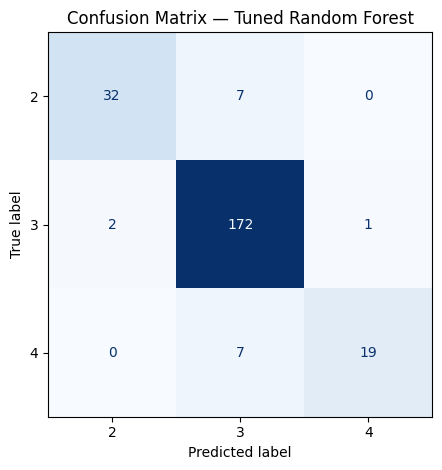

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[2, 3, 4])
plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Tuned Random Forest')
plt.tight_layout()
plt.show()


**Observation:**  
The confusion matrix shows how well the Tuned Random Forest classifies each performance rating. Rating 3 (majority class) is predicted most accurately. Rating 2 and 4 (minority classes) show some misclassification into Rating 3, expected given class imbalance. Overall diagonal dominance confirms the model's strong predictive ability.

**Observation:**  
The tuned model shows slightly lower test accuracy (0.9292) and F1 Macro (0.8852) compared to baseline RF (0.9375, 0.8983). The parameter grid constrained tree depth to max_depth=10, which limited model capacity on this dataset. Baseline Random Forest remains the stronger performer and will be used as the final model.

## 16. Cross-Validation — Baseline Random Forest

In [29]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(baseline_models['Random Forest'], X, y, cv=5, scoring='f1_macro')
print('5-Fold Cross-Validation F1 Macro Scores:', np.round(cv_scores, 4))
print(f'Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}')

5-Fold Cross-Validation F1 Macro Scores: [0.8454 0.9163 0.9768 0.8371 0.8585]
Mean: 0.8868 | Std: 0.0528


**Observation:**  
The 5-fold CV F1 Macro scores for the Baseline Random Forest are [0.8454, 0.9163, 0.9768, 0.8371, 0.8585] with Mean=0.8868 and Std=0.0528. Fold 3 shows a notably higher score (0.9768), which accounts for the moderate standard deviation. The mean CV score (0.8868) is close to the baseline RF test F1 (0.8983), confirming that the model generalizes well across different data splits without serious overfitting.

## 17. SHAP Explainability — Feature Impact

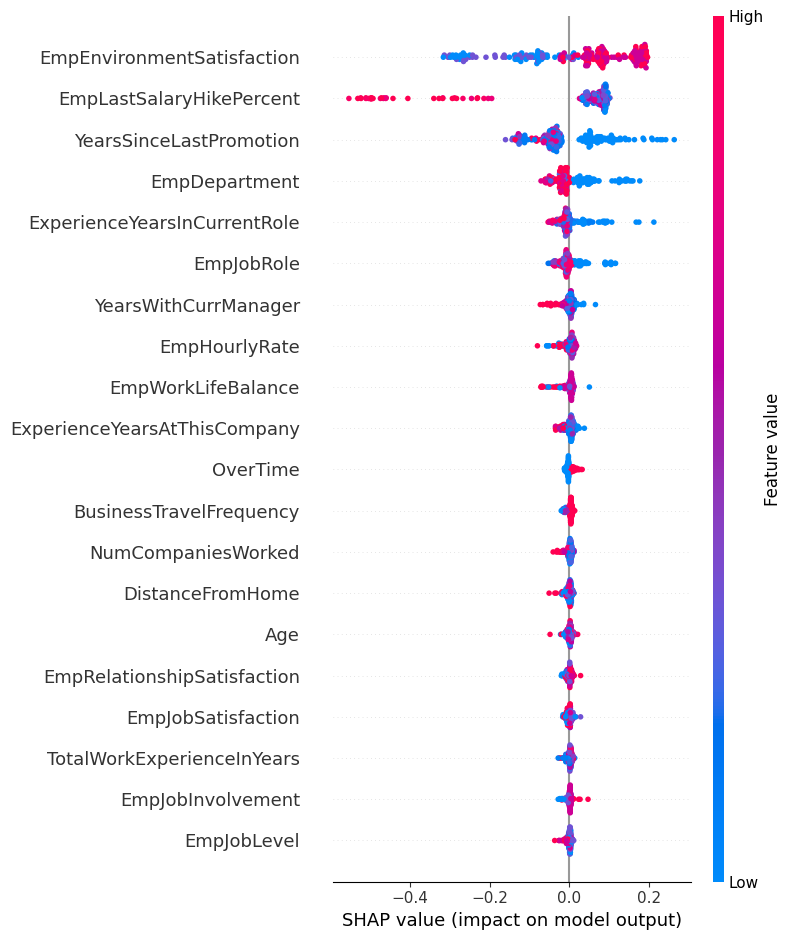

In [35]:
import shap

rf_model = baseline_models['Random Forest'].named_steps['model']
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values[:, :, 1]

shap.summary_plot(sv, X_test, feature_names=list(X_test.columns), show=True)

**Observation:**  
The SHAP summary plot confirms that `EmpLastSalaryHikePercent`, `EmpEnvironmentSatisfaction`, and `YearsSinceLastPromotion` are the **top contributors** to model predictions — consistent with the Random Forest feature importance in Section 11. Higher salary hike pushes predictions toward Rating 3/4, while longer time since promotion reduces the score. SHAP provides individual-level explainability, satisfying Deliverable 2 more rigorously.

## 18. Model Comparison

              Model     Type  Accuracy  F1 Macro
Logistic Regression Baseline    0.8250    0.7181
      Decision Tree Baseline    0.9000    0.8476
      Random Forest Baseline    0.9375    0.8983
  Gradient Boosting Baseline    0.9292    0.8845
      Random Forest    Tuned    0.9292    0.8852


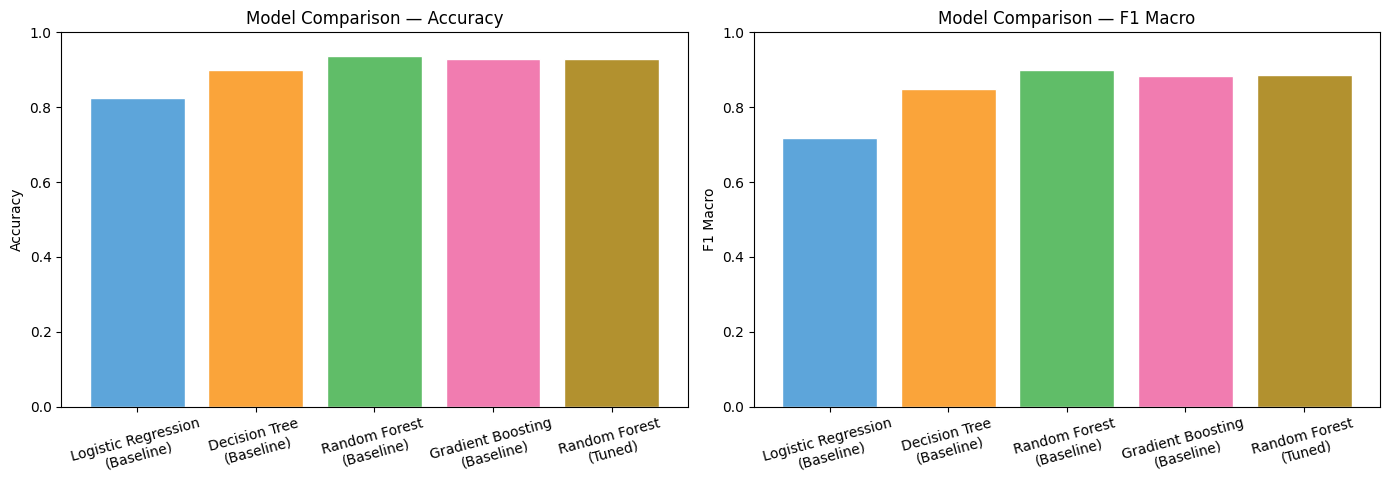

In [31]:
comparison_data = []
for name, result in baseline_results.items():
    comparison_data.append({'Model': name, 'Type': 'Baseline',
                             'Accuracy': result['Accuracy'], 'F1 Macro': result['F1 Macro']})
comparison_data.append({'Model': 'Random Forest', 'Type': 'Tuned',
                         'Accuracy': round(tuned_acc, 4), 'F1 Macro': round(tuned_f1, 4)})

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = [f"{r['Model']}\n({r['Type']})" for r in comparison_data]
accs = [r['Accuracy'] for r in comparison_data]
f1s = [r['F1 Macro'] for r in comparison_data]

colors = ['#5DA5DA', '#FAA43A', '#60BD68', '#F17CB0', '#B2912F']
axes[0].bar(labels, accs, color=colors, edgecolor='white')
axes[0].set_title('Model Comparison — Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(labels, f1s, color=colors, edgecolor='white')
axes[1].set_title('Model Comparison — F1 Macro')
axes[1].set_ylabel('F1 Macro')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Observation:**  
**Baseline Random Forest** achieves the best performance across both metrics — Accuracy=0.9375 and F1 Macro=0.8983 — outperforming all other models including the tuned variant. Gradient Boosting is competitive (F1=0.8845) but falls slightly behind. Logistic Regression performs lowest due to the non-linear nature of the data. **Baseline Random Forest is selected as the final model** for deployment.

## 19. Final Model — Prediction System (Deliverable 3)

In [32]:
import joblib

# Save the final model
joblib.dump(baseline_models['Random Forest'], 'inx_employee_performance_model.pkl')
print('Final model saved as: inx_employee_performance_model.pkl')

# Save the feature column order
joblib.dump(list(X.columns), 'inx_feature_columns.pkl')
print('Feature columns saved as: inx_feature_columns.pkl')

# Save the label encoders for deployment inference
joblib.dump(le_dict, 'inx_label_encoders.pkl')
print('Label encoders saved as: inx_label_encoders.pkl')


Final model saved as: inx_employee_performance_model.pkl
Feature columns saved as: inx_feature_columns.pkl
Label encoders saved as: inx_label_encoders.pkl


In [33]:
# Sample prediction demonstration
sample_employee = X_test.iloc[[0]]
predicted_rating = baseline_models['Random Forest'].predict(sample_employee)
actual_rating = y_test.iloc[0]

print('Sample Employee Prediction:')
print(f'  Predicted Performance Rating : {predicted_rating[0]}')
print(f'  Actual Performance Rating    : {actual_rating}')

Sample Employee Prediction:
  Predicted Performance Rating : 3
  Actual Performance Rating    : 3


**Observation:**  
The final Baseline Random Forest model is saved using `joblib` for reuse in deployment. The model accepts 26 encoded employee features and predicts one of three performance ratings: 2 (Low), 3 (Good), or 4 (Excellent). This satisfies Deliverable 3 — a trained model ready to screen employee performance during hiring.

## 20. Recommendations to Improve Employee Performance (Deliverable 4)

Based on the analysis, the following recommendations are proposed for INX Future Inc.:

---

### 1. Reward High Performers with Competitive Salary Hikes
`EmpLastSalaryHikePercent` is the **single most important predictor** of performance. Employees who receive higher salary hikes are significantly more likely to be high performers. INX should ensure merit-based salary review cycles and avoid flat hike structures that do not differentiate performance levels.

---

### 2. Invest in Work Environment and Culture
`EmpEnvironmentSatisfaction` is the second most influential factor. Improving physical workspace quality, reducing micromanagement, promoting psychological safety, and fostering teamwork will raise the overall performance baseline — especially in the Sales and Finance departments where performance is comparatively lower.

---

### 3. Establish Timely Promotion Pathways
`YearsSinceLastPromotion` shows that employees stuck in their roles for long periods tend to underperform. INX should implement a structured promotion framework — clearly defined criteria, transparent timelines, and regular career conversations — to prevent stagnation-driven disengagement.

---

### 4. Address Department-Specific Gaps
- **Sales, Finance, and HR** departments have the highest proportion of Rating 2 employees. Targeted L&D programs, mentoring from high performers, and department-specific KPIs are recommended.
- **Development and Data Science** departments perform well — their management practices and team structures can be studied and replicated across other departments.

---

### 5. Improve Job Involvement and Role Clarity
`EmpWorkLifeBalance` shows a positive link with performance (0.124). Encouraging healthy work-life balance through flexible policies and manageable workloads can support sustained performance across all departments.

---

### 6. Use the Predictive Model During Hiring
The trained Random Forest model can be integrated into INX's hiring pipeline to predict the likely performance rating of candidates based on their profile. This enables data-driven hiring decisions and reduces the risk of onboarding low-performing employees.

---

**Summary:**  
The core message from this analysis is that **employee performance is not random** — it is driven by recognizable, measurable factors. By addressing salary recognition, work environment, and career growth, INX Future Inc. can systematically elevate performance without penalizing individuals in a way that harms company-wide morale.

In [34]:
from google.colab import files
files.download('inx_employee_performance_model.pkl')
files.download('inx_feature_columns.pkl')
files.download('inx_label_encoders.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>